# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for large aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [34]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
cleanData = pd.read_csv('cleaned_plane_data.csv')
cleanData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73813 entries, 0 to 73812
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                73813 non-null  object 
 1   Investigation.Type      73813 non-null  object 
 2   Accident.Number         73813 non-null  object 
 3   Event.Date              73813 non-null  object 
 4   Location                73771 non-null  object 
 5   Country                 73618 non-null  object 
 6   Airport.Code            42297 non-null  object 
 7   Airport.Name            44172 non-null  object 
 8   Injury.Severity         73330 non-null  object 
 9   Aircraft.damage         73813 non-null  object 
 10  Registration.Number     72773 non-null  object 
 11  Make                    73813 non-null  object 
 12  Model                   73813 non-null  object 
 13  Amateur.Built           73813 non-null  object 
 14  Number.of.Engines       69291 non-null

C:\Users\Jason.DESKTOP-MNVBQQF\AppData\Local\Temp\ipykernel_28536\1522519028.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  cleanData = pd.read_csv('cleaned_plane_data.csv')


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [22]:
cleanData['Number.of.Passengers'] = cleanData['Number.of.Passengers'].astype(int)
cleanData = cleanData[cleanData['Number.of.Passengers'] > 0]
small = cleanData[cleanData['Number.of.Passengers'] <= 20]
large = cleanData[cleanData['Number.of.Passengers'] > 20]


#### Analyzing Makes

Explore the human injury risk profile for small and large Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

C:\Users\Jason.DESKTOP-MNVBQQF\AppData\Local\Temp\ipykernel_28536\3610062460.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small['Injury.Fraction'] = 100*( (small['Total.Fatal.Injuries'].fillna(0).astype(int) + small['Total.Serious.Injuries'].fillna(0).astype(int))
C:\Users\Jason.DESKTOP-MNVBQQF\AppData\Local\Temp\ipykernel_28536\3610062460.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  large['Injury.Fraction'] = 100*( (large['Total.Fatal.Injuries'].fillna(0).astype(int) + large['Total.Serious.In

count    62395.000000
mean         0.475663
std          1.176262
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         20.000000
Name: Total.Fatal.Injuries, dtype: float64

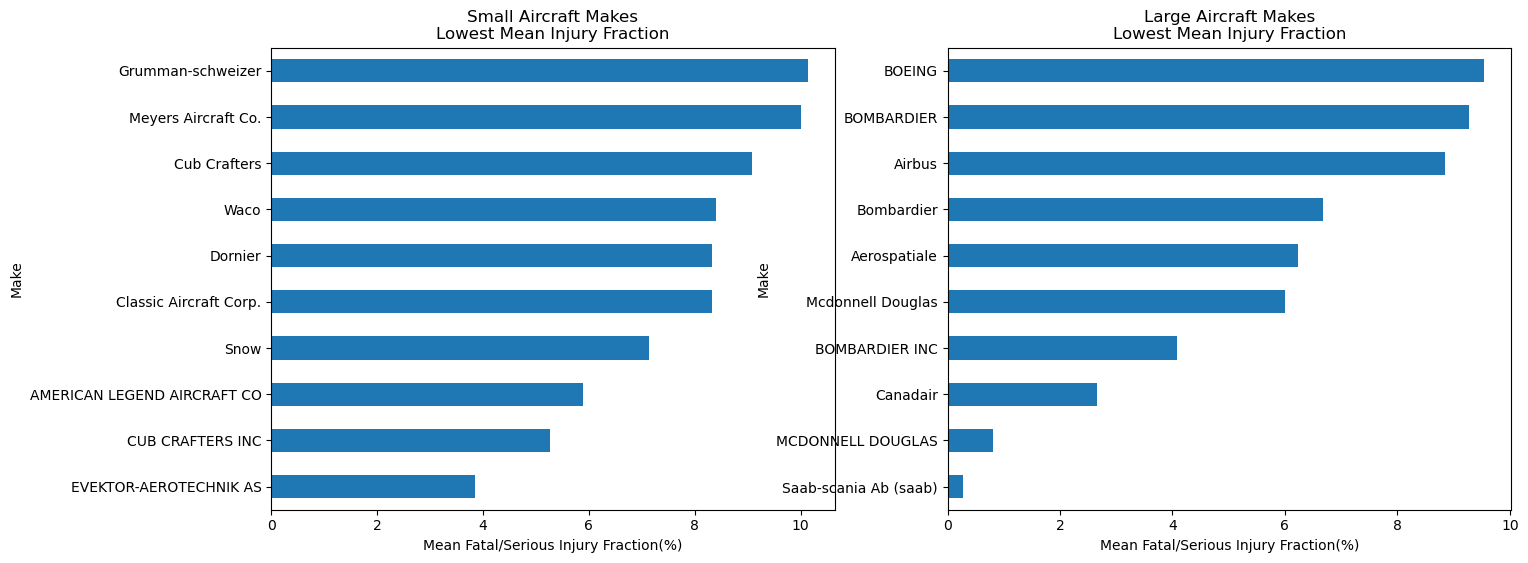

In [ ]:

small['Injury.Fraction'] = ( (small['Total.Fatal.Injuries'].fillna(0).astype(int) + small['Total.Serious.Injuries'].fillna(0).astype(int))
                            / small['Number.of.Passengers'] )

large['Injury.Fraction'] = ( (large['Total.Fatal.Injuries'].fillna(0).astype(int) + large['Total.Serious.Injuries'].fillna(0).astype(int))
                            / large['Number.of.Passengers'] )
# I only want makes with att least 10 accidents to filter out any outliers
small_filtered = small.groupby('Make').filter(lambda x: len(x) >= 10)
large_filtered = large.groupby('Make').filter(lambda x: len(x) >= 10)

# sort the 15 lowest for each group(changed to 10 later for the future code)
ten_small = small_filtered.groupby('Make')['Injury.Fraction'].mean().sort_values().head(10)
ten_large = large_filtered.groupby('Make')['Injury.Fraction'].mean().sort_values().head(10)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ten_small.plot(kind='barh', ax=axes[0])
axes[0].set_title('Small Aircraft Makes\nLowest Mean Injury Fraction')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction(%)')

ten_large.plot(kind='barh', ax=axes[1])
axes[1].set_title('Large Aircraft Makes\nLowest Mean Injury Fraction')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction(%)')
small['Total.Fatal.Injuries'].describe()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

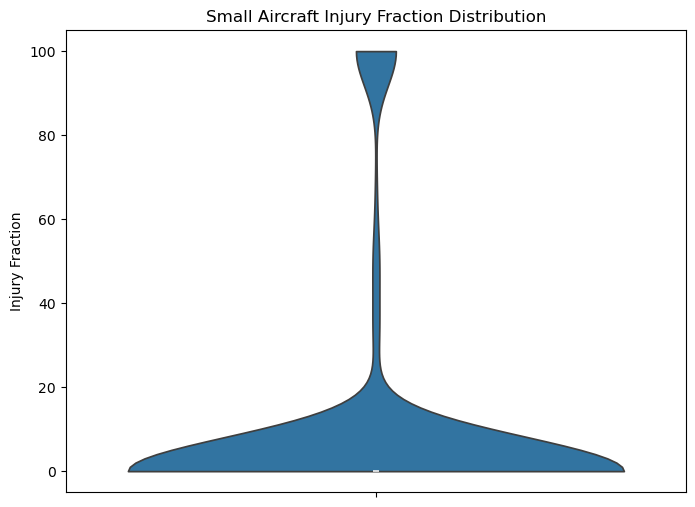

In [42]:
# Violin plot for small aircraft
lowest_small_makes = ten_small.index

# Keep only rows from those makes
small_plot_data = small_filtered[
    small_filtered['Make'].isin(lowest_small_makes)
]
plt.figure(figsize=(8, 6))
sns.violinplot(
    data=small_plot_data,
    y='Injury.Fraction',
    cut = 0

)

plt.title('Small Aircraft Injury Fraction Distribution')
plt.ylabel('Injury Fraction')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

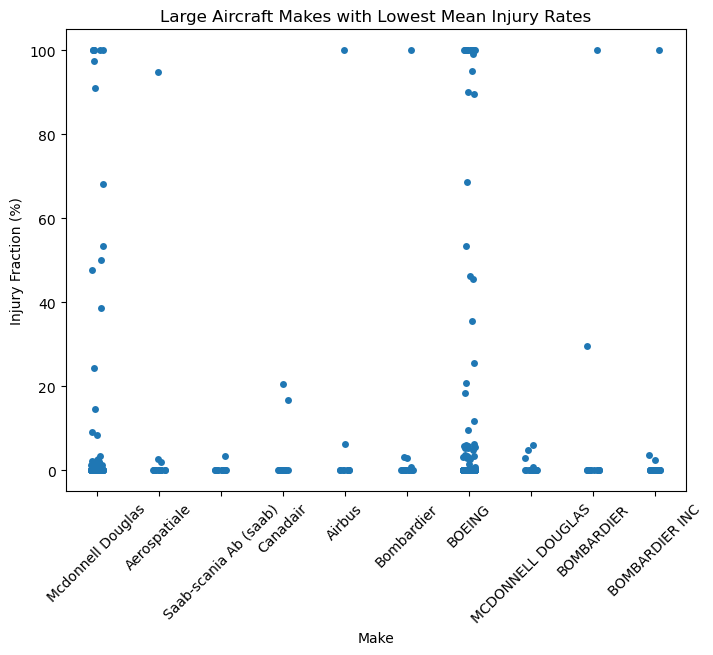

In [43]:
# Keep only the 10 safest large makes
lowest_large_makes = ten_large.index

large_plot_data = large_filtered[
    large_filtered['Make'].isin(lowest_large_makes)
]

# Strip plot
plt.figure(figsize=(8, 6))

sns.stripplot(
    data=large_plot_data,
    x='Make',
    y='Injury.Fraction'
)

plt.xticks(rotation=45)
plt.title('Large Aircraft Makes with Lowest Mean Injury Rates')
plt.ylabel('Injury Fraction (%)')

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

C:\Users\Jason.DESKTOP-MNVBQQF\AppData\Local\Temp\ipykernel_28536\1494484119.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small['Destroyed'] = (small['Aircraft.damage'] == 'Destroyed').astype(int)
C:\Users\Jason.DESKTOP-MNVBQQF\AppData\Local\Temp\ipykernel_28536\1494484119.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  large['Destroyed'] = (large['Aircraft.damage'] == 'Destroyed').astype(int)


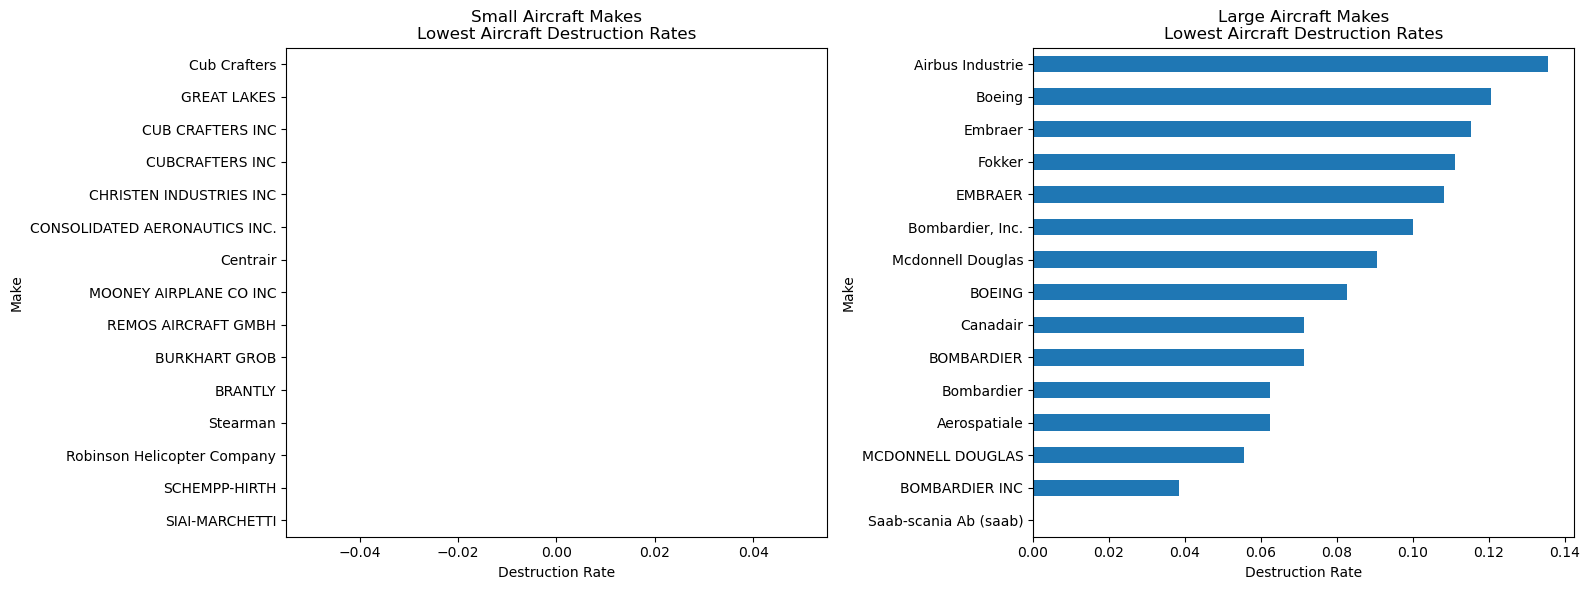

In [50]:
# Create destruction indicator
small['Destroyed'] = (small['Aircraft.damage'] == 'Destroyed').astype(int)
large['Destroyed'] = (large['Aircraft.damage'] == 'Destroyed').astype(int)

# Keep only makes with at least 15 accidents
small_destroy_filtered = small.groupby('Make').filter(lambda x: len(x) >= 10) #changed threshold to 30 because I got 0% destroyed rates otherewise
large_destroy_filtered = large.groupby('Make').filter(lambda x: len(x) >= 10)

# Mean destruction rate by make
small_destroy_rate = (
    small_destroy_filtered.groupby('Make')['Destroyed']
    .mean()
    .sort_values()
    .head(15)
)

large_destroy_rate = (
    large_destroy_filtered.groupby('Make')['Destroyed']
    .mean()
    .sort_values()
    .head(15)
)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

small_destroy_rate.plot(kind='barh', ax=axes[0])
axes[0].set_title('Small Aircraft Makes\nLowest Aircraft Destruction Rates')
axes[0].set_xlabel('Destruction Rate')

large_destroy_rate.plot(kind='barh', ax=axes[1])
axes[1].set_title('Large Aircraft Makes\nLowest Aircraft Destruction Rates')
axes[1].set_xlabel('Destruction Rate')

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In terms of fraction destroyed and fraction fatally injured/seriously injured, there are a couple of great options. First of all, for the small planes, any of the CUBCRAFTERs or names similar to those. Also, Snow, WACO, and Dornier seem like good options for reducing injury. For larger planes, names like Boeing, BOMBARDIER and Mcdonell douglas seem like great options for aircrafts that arent destroyed very often. Boeing, bombardier, and Mcdonell douglas also seemed to do well in terms of having low injury rates. 

One thing that really interested me was that a lot of the smaller aircrafts had 0% destroyed rates. I had to raise the threshold to 30 just to get a bar chart that isn't entirely composed of 0% destroyed

One thing I noticed during my plotting and identifying of the safest plane types is that I did not clean my data as well as I could have. While I identified a lot of the obvious mistakes and white space errors, issues like CUB CRAFTERS INC vs CUBCRAFTERSINC still would register as separate

Another thing I noticed, and I presume this applies to all accidents, even though I only looked at the 15 lowest accident rates(mean wise) was that there were not so many 50% or 60% fatality rates. This makes a lot of sense to me, as if 50 to 60% of the passengers pass away, its going to be difficult for the other half of the passengers to survive. Thus, its fair that mostly 0% fatality rate with some 100s sprinkled in. I also noticed, that for bombardier, and some others, there was just 1 really bad accident with a 100 fatality rate, suggesting that the threshold might still be too low.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

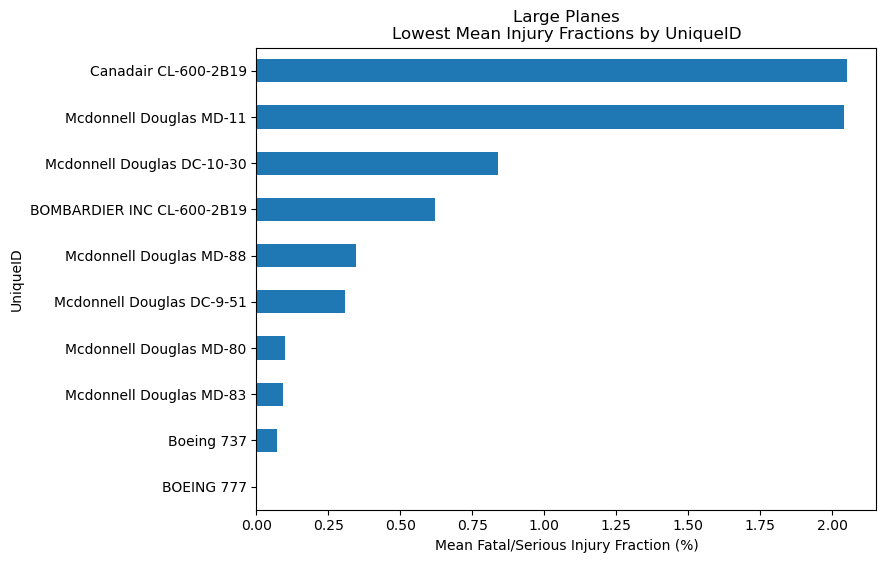

In [ ]:
large_id_filtered = large.groupby('UniqueID').filter(lambda x: len(x) >= 10)
#filter to remove outlier
large_id_means = (
    large_id_filtered.groupby('UniqueID')['Injury.Fraction']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(8, 6))

large_id_means.plot(kind='barh')
plt.title('Large Planes\nLowest Mean Injury Fractions by UniqueID')
plt.xlabel('Mean Fatal/Serious Injury Fraction (%)')

plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

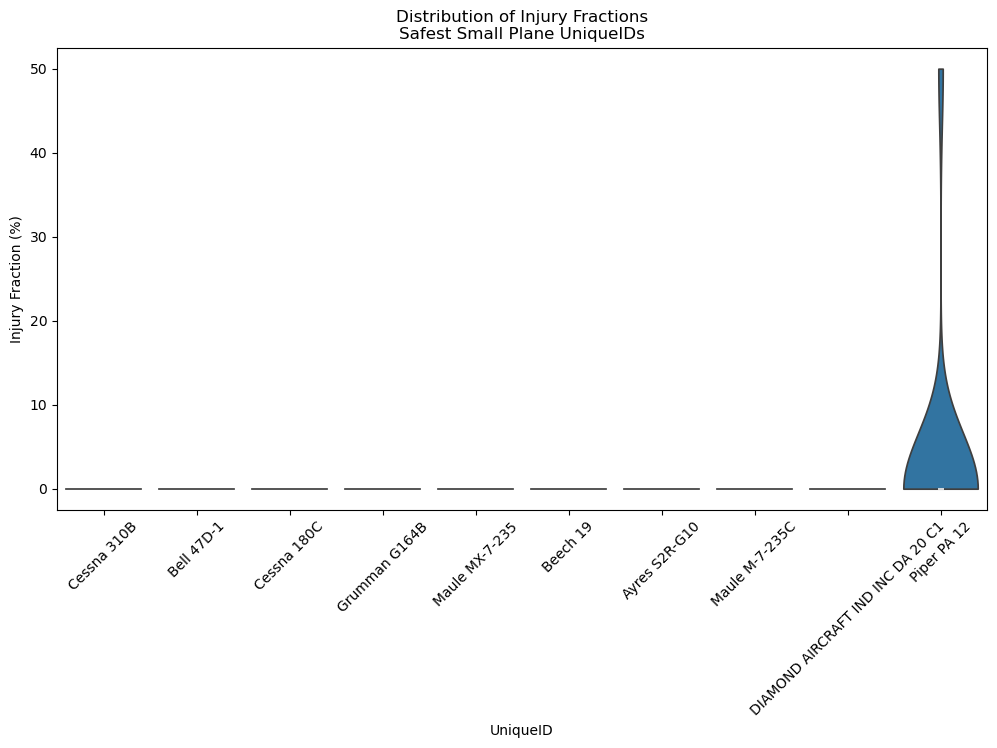

In [56]:
small_id_filtered = small.groupby('UniqueID').filter(lambda x: len(x) >= 10)

small_id_means = (
    small_id_filtered.groupby('UniqueID')['Injury.Fraction']
    .mean()
    .sort_values()
    .head(10)   #limited to 10 lowest
)

small_plot_ids = small_id_means.index

small_plot_data = small_id_filtered[
    small_id_filtered['UniqueID'].isin(small_plot_ids)
]

# Violin plot
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=small_plot_data,
    x='UniqueID',
    y='Injury.Fraction',
    cut=0
)

plt.xticks(rotation=45)
plt.title('Distribution of Injury Fractions\nSafest Small Plane UniqueIDs')
plt.ylabel('Injury Fraction (%)')

plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

I noticed that in terms of the large airplanes, there are a lot of Mcdonell and Boeing. Specifically the Boeing 777 and Boeing 737 are exceptional among large airplanes, with honorable mentions to the mcdonnell MD83. If we are speaking about the makes that stood out, both Mcdonell and boeing were the makes that stood out in terms of fractions of injury

For the small planes, because I was limited to a threshold of 10, there were a lot of planes that had 0 injuries. Among those small planes, the Cessna Make really stood out as it had multiple plane models in the top 10 of injury fraction. The specific models that really stoop out were the Cessna 3108, the Cessna 180C, and the Beech 19, among others that were at 0%

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

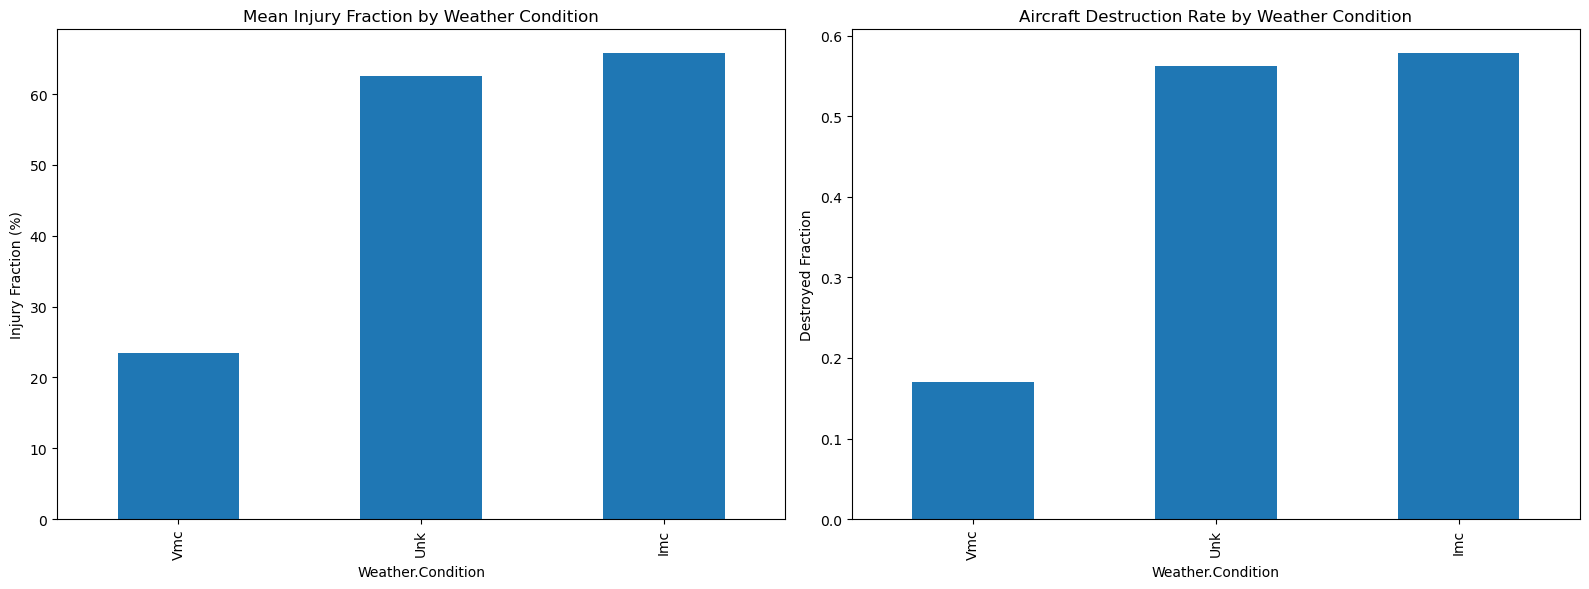

In [ ]:
# -----------------------------
# WEATHER CONDITION ANALYSIS
# -----------------------------

# Filter weather conditions with at least 10 accidents
weather_filtered = cleanData.groupby('Weather.Condition').filter(
    lambda x: len(x) >= 10
)

# find the mean injury fraction for each weather condition
weather_injury = (
    weather_filtered.groupby('Weather.Condition')['Injury.Fraction']
    .mean()
    .sort_values()
)

# find the destroyed aircrafts for each wewather conditioon
weather_filtered['Destroyed'] = (
    weather_filtered['Aircraft.damage']
    .str.strip()
    .str.lower()
    .eq('destroyed')
).astype(int)

weather_destroyed = (
    weather_filtered.groupby('Weather.Condition')['Destroyed']
    .mean()
    .sort_values()
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

weather_injury.plot(kind='bar', ax=axes[0])
axes[0].set_title('Mean Injury Fraction by Weather Condition')
axes[0].set_ylabel('Injury Fraction (%)')

weather_destroyed.plot(kind='bar', ax=axes[1])
axes[1].set_title('Aircraft Destruction Rate by Weather Condition')
axes[1].set_ylabel('Destroyed Fraction')

plt.tight_layout()
plt.show()

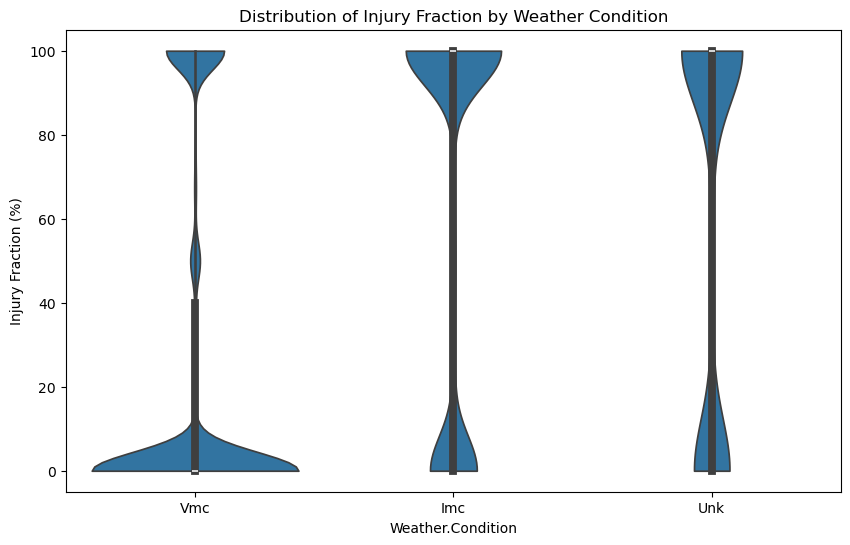

In [58]:
# Distribution plot for weather condition

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=weather_filtered,
    x='Weather.Condition',
    y='Injury.Fraction',
    cut=0
)

plt.title('Distribution of Injury Fraction by Weather Condition')
plt.ylabel('Injury Fraction (%)')

plt.show()

For weather conditions, I analyzed how the different weather conditions impacted what fraction of severe injury there was. In this scenario, VMC refers to relatively clear conditions, IMC refers to poor conditions, and UNK means unknown weather. After analyzing the data, it is clear that the poor conditions cause by far the most injury severity and destroyed aircrafts, with the unknown conditions close behind. This makes a lot of sense, as in poor meteorological conditions, it will be a lot harder to pilot safely.

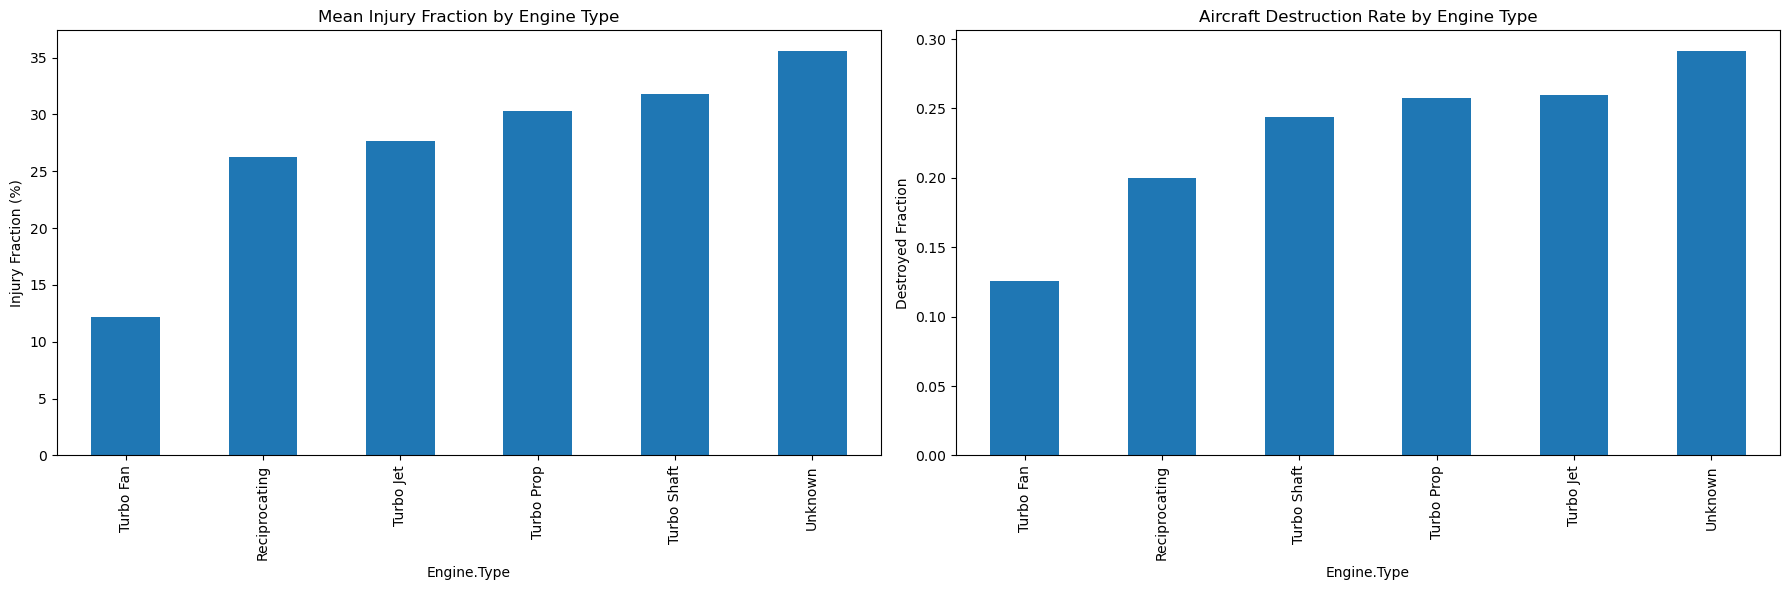

In [59]:
# -----------------------------
# ENGINE TYPE ANALYSIS
# -----------------------------

# Filter the engines with 10 accidnets
engine_filtered = cleanData.groupby('Engine.Type').filter(
    lambda x: len(x) >= 10
)

# find the mean injury fraction for each engine type
engine_injury = (
    engine_filtered.groupby('Engine.Type')['Injury.Fraction']
    .mean()
    .sort_values()
)

# find destruction rate
engine_filtered['Destroyed'] = (
    engine_filtered['Aircraft.damage']
    .str.strip()
    .str.lower()
    .eq('destroyed')
).astype(int)

engine_destroyed = (
    engine_filtered.groupby('Engine.Type')['Destroyed']
    .mean()
    .sort_values()
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

engine_injury.plot(kind='bar', ax=axes[0])
axes[0].set_title('Mean Injury Fraction by Engine Type')
axes[0].set_ylabel('Injury Fraction (%)')

engine_destroyed.plot(kind='bar', ax=axes[1])
axes[1].set_title('Aircraft Destruction Rate by Engine Type')
axes[1].set_ylabel('Destroyed Fraction')

plt.tight_layout()
plt.show()

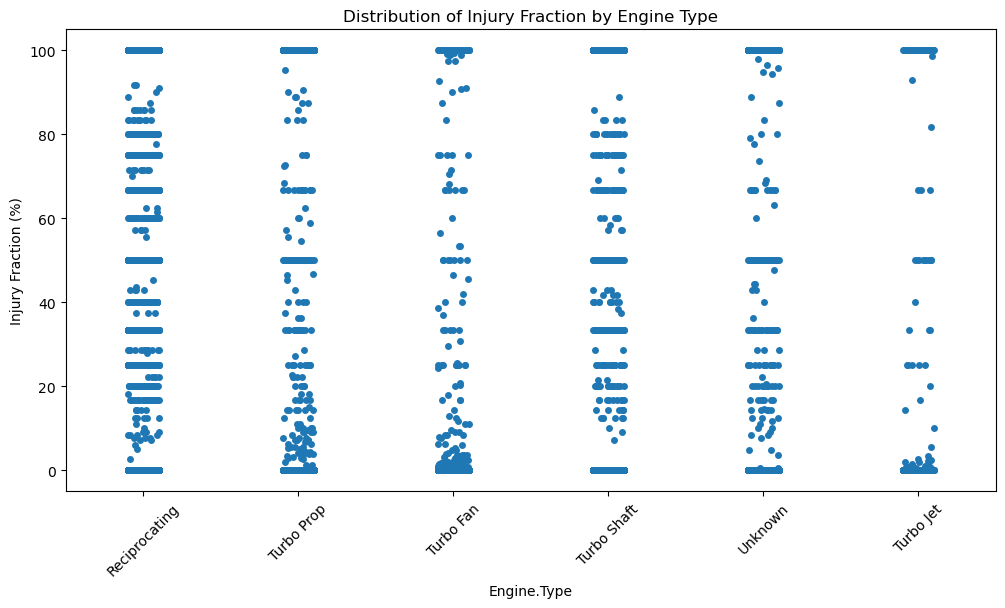

In [60]:
# Distribution plot for engine type

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=engine_filtered,
    x='Engine.Type',
    y='Injury.Fraction'
)

plt.xticks(rotation=45)
plt.title('Distribution of Injury Fraction by Engine Type')
plt.ylabel('Injury Fraction (%)')

plt.show()

The engine type analysis showed meaningful differences in injury severity and aircraft destruction outcomes across engine categories. Some of the engine types, like the Turbo Fan showed a significant decrease in the injury severity rates and aircraft destruction rates. I also noticed that the unknown engine had by far the most injury severity and aircraft destruction rates. Looking at the strip plot, we can see that the turbo jet has a lot of fatalities or a very low fatality rate, with very few ~50% injury severity rates.